In [78]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


## Data exploration

In [79]:
music_info_df = pd.read_csv('../data/music_recommendation_system/msd_music_info.csv')
print(music_info_df.head())
# print("Shape: ")
# print(music_info_df.shape)
# print("Columns:  ")
# print(music_info_df.columns)

             track_id             name           artist  \
0  TRIOREW128F424EAF0   Mr. Brightside      The Killers   
1  TRRIVDJ128F429B0E8       Wonderwall            Oasis   
2  TROUVHL128F426C441  Come as You Are          Nirvana   
3  TRUEIND128F93038C4      Take Me Out  Franz Ferdinand   
4  TRLNZBD128F935E4D8            Creep        Radiohead   

                                 spotify_preview_url              spotify_id  \
0  https://p.scdn.co/mp3-preview/4d26180e6961fd46...  09ZQ5TmUG8TSL56n0knqrj   
1  https://p.scdn.co/mp3-preview/d012e536916c927b...  06UfBBDISthj1ZJAtX4xjj   
2  https://p.scdn.co/mp3-preview/a1c11bb1cb231031...  0keNu0t0tqsWtExGM3nT1D   
3  https://p.scdn.co/mp3-preview/399c401370438be4...  0ancVQ9wEcHVd0RrGICTE4   
4  https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...  01QoK9DA7VTeTSE3MNzp4I   

                                                tags genre  year  duration_ms  \
0  rock, alternative, indie, alternative_rock, in...   NaN  2004       222200   
1 

In [80]:
music_info_df = music_info_df.drop(columns='spotify_preview_url')

In [81]:
music_info_df.shape

(50683, 20)

In [82]:
music_info_df_clean = music_info_df.dropna(subset=['tags'])
music_info_df_clean

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,0.918,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,0.892,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,0.826,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,0.664,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,0.430,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50675,TRXWSIN128F9339A11,Infinite Love Song,Maximilian Hecker,2eIVm8hPf59hUS2PrdoGBa,"electronic, indie_pop, love",NaN,2002,285800,0.549,0.675,10,-7.431,1,0.0332,0.129000,0.437000,0.1220,0.551,99.679,4
50677,TRPIGDW12903CDEB2D,Slip of the Lip,Fact,0PG7cpyNzRehf1YNIbAsol,"alternative_rock, punk_rock",Rock,2010,183640,0.423,0.980,2,-4.068,1,0.1840,0.000986,0.000002,0.3790,0.224,100.080,4
50679,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,3wkdfXGf5JYErW4b35zP2h,"rock, alternative_rock, japanese, cover",NaN,2004,275133,0.351,0.693,0,-6.811,1,0.1200,0.000940,0.000049,0.1920,0.450,200.350,4
50680,TRZRODK128F92D68D7,The Revelation,coldrain,1gXMORZRGA40PE9rDE9cja,"metal, metalcore, post_hardcore",NaN,2014,254826,0.434,0.975,10,-3.092,0,0.2680,0.000108,0.001410,0.1630,0.282,158.025,4


In [83]:
music_info_df_clean['artist'].value_counts()

artist
The Rolling Stones    132
Radiohead             111
Autechre              105
Tom Waits             100
Bob Dylan              98
                     ... 
雅-MIYAVI-               1
Hi-Standard             1
Kana                    1
Maximilian Hecker       1
ACIDMAN                 1
Name: count, Length: 8065, dtype: int64

In [84]:
#music_info_df_clean['genre'].value_counts()
print(music_info_df_clean[music_info_df_clean['genre']=='Latin'].value_counts())

track_id            name               artist           spotify_id              tags                                                                                            genre  year  duration_ms  danceability  energy  key  loudness  mode  speechiness  acousticness  instrumentalness  liveness  valence  tempo    time_signature
TRSQAWU128F92EA20F  La Tortura         Shakira          0ofDrTTcinCUxm7wqCLPQa  electronic, pop, female_vocalists, singer_songwriter, dance, 00s                                Latin  2011  213106       0.741         0.7790  0    -5.904    1     0.0421       0.023000      0.000788          0.1200    0.834    100.001  4                 1
TROJOFW128F4235E4F  Tonto              Battles          1wlvLwSy8jXzCUsWFJf8wc  electronic, experimental, indie_rock, instrumental, post_rock                                   Latin  2007  463146       0.512         0.7390  2    -6.943    0     0.0373       0.011200      0.269000          0.0835    0.513    121.527  4          

In [85]:
print(music_info_df_clean.sort_values(by="danceability"))

                 track_id                        name          artist  \
42732  TRDZLJH128F428CB73         Cheerleader Corpses   Pig Destroyer   
1624   TRXRUTR128F4296932                         Uno            Muse   
21348  TRWRQGH12903CD60DA            Song for Someone              U2   
23621  TRFUMNQ128F933906A  240 Years Before Your Time  The Black Keys   
838    TRCTFEM12903CE53CF                     Sunburn            Muse   
...                   ...                         ...             ...   
2689   TRSCBKV128F427888D                    Teachers       Daft Punk   
27995  TRUVXNX128F92F1901              State of Shock    The Jacksons   
14921  TRPLTOV128EF362B0D           Funky Cold Medina        Tone-Lōc   
15027  TRDWQSH128F92DE586                     Go Girl         Pitbull   
29777  TRUYEBL128F92C4F0A                Leave Me Now         Herbert   

                   spotify_id  \
42732  53E0iLvaSlApDIcIdL7Q3G   
1624   2BfBmr6CluaQemIHPC5XK9   
21348  03xYrKFtq1rdOE595

Text(0, 0.5, 'Genre')

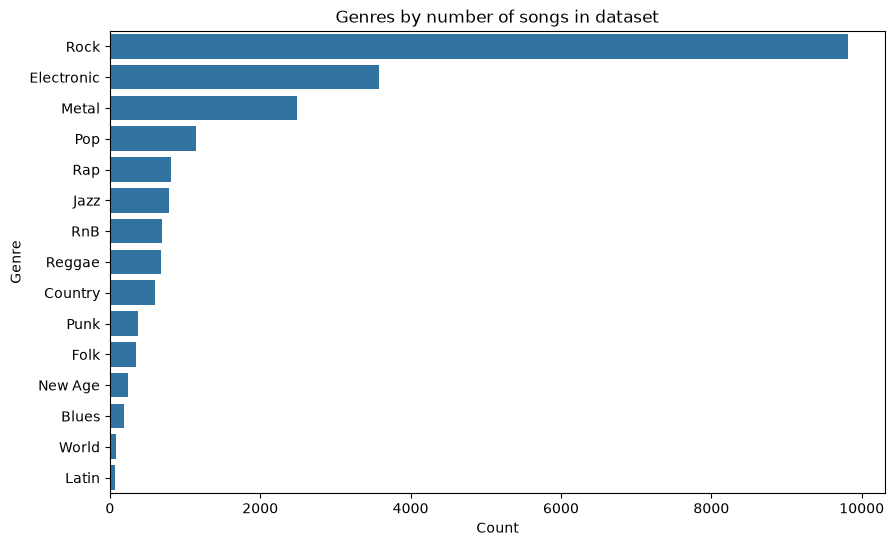

In [86]:
plt.figure(figsize=(10,6))
sns.countplot(y='genre', data=music_info_df_clean, order=music_info_df_clean['genre'].value_counts().index[:])
plt.title('Genres by number of songs in dataset')
plt.xlabel('Count')
plt.ylabel('Genre')

## Testing Dataset's Spotify IDs on Spotify API

In [87]:
import spotipy
from spotipy import SpotifyOAuth
import os
from dotenv import dotenv_values

In [88]:
# set up spotify
CURRENT_DIR = os.getcwd()
secrets_path = os.path.abspath(os.path.join(CURRENT_DIR, '../../.env.dev'))
secrets = dotenv_values(secrets_path)
SCOPE_LIST=['user-read-currently-playing','user-modify-playback-state','user-read-playback-state', 'user-read-private', 'playlist-modify-public', 'playlist-modify-private', 'ugc-image-upload']
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(client_id=secrets['SPOTIFY_CLIENT_ID'], client_secret=secrets['SPOTIFY_CLIENT_SECRET'],
redirect_uri=secrets['SPOTIFY_REDIRECT_URI'], scope =SCOPE_LIST))

In [89]:
song_to_add = []
search = 'Come As you Are'
new_song_uri=''
match = music_info_df_clean[(music_info_df_clean['name'].str.lower()==search.lower())]
if match.empty:
    print("Song not found")
else:
    new_song_uri = match.spotify_id.values[0]



In [90]:
# successfully adds song to queue 
# sp.add_to_queue(uri=new_song_uri)

## Recommender System 1: Deep Autoencoder
recommends songs based on sound and feel
uses acoustic features and tags 

In [91]:

# for recommender model 1
from sklearn.preprocessing import MinMaxScaler 
from sklearn.feature_extraction.text import TfidfVectorizer 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

In [92]:
# normalize continuous numerical audio features, so excluding key which is numeric
numerical_cols = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
scaler = MinMaxScaler() # scales data to fit between 1
scaled_numerical = scaler.fit_transform(music_info_df_clean[numerical_cols]) # takes all the data from those columns and normalizes them to fit between 0 and 1

In [93]:
# vectorizing tags using TF-IDF

cleaned_tags = music_info_df_clean['tags'].str.replace(',',' ').str.replace('_', ' ')
tfidf = TfidfVectorizer(max_features=200) 
tfidf_matrix = tfidf.fit_transform(cleaned_tags).toarray() # turns words into numbers and how often they appear in dataaet

In [94]:
X_features = np.hstack((scaled_numerical, tfidf_matrix))
X_features.shape

(49556, 104)

In [95]:
class AutoencoderDataset(Dataset):
    def __init__(self, features_array):
        self.features = torch.tensor(features_array, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self,idx):
        # autoencoders map input to themselves as targets
        # since model is trying to reconstruct input, passes iputs and targets directly to pytorch loss functions
        return self.features[idx], self.features[idx]
        

In [96]:
#split features into 85 train 15 val
X_train, X_val = train_test_split(X_features, test_size=0.15, random_state=42)

# create loaders for batching
train_loader = DataLoader(AutoencoderDataset(X_train), batch_size=64, shuffle=True) 
val_loader = DataLoader(AutoencoderDataset(X_val), batch_size=64, shuffle=False) # shuffle is useful during training only

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 659, Val batches: 117


In [97]:
# reduces noise
# compare songs using their compressed 16 dimensional latent representations
# efficient
# learns non-linear relationships, like the word vector
# base 2 batch size to fit efficiently in memory cache
# size 16 is enough to capture enough information about a song
# relu as hidden layers so model learns non-linear patterns
class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim = 16):
        super(DeepAutoencoder, self).__init__()

        # encoder compress features down to 16 dimensions
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid() # output bounded between 0 and 1 to match minmax scaler
        )
    def forward(self, x):
        latent = self.encoder(x) # latent is where you compare
        reconstructed = self.decoder(latent) # reconstructs input
        return reconstructed, latent

In [98]:
# determine hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using: {device}")

Using: mps


In [99]:
# model instantiated
input_dimension = X_features.shape[1] # so 9 continuous acoustic features + 95 vocabulary columns generated by TF-IDF
model = DeepAutoencoder(input_dim = input_dimension).to(device)

In [100]:
# setup mean squared loss and adam optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # optimizer factors in everything going into the model at a learning rate of 0.001


In [101]:
# Training loop
NUM_EPOCHS = 15
model.train() # starts training loop
for epoch in range(NUM_EPOCHS):
    train_loss = 0.0 # starts train loss value
    for data, _ in train_loader: # we just want to iterate data
        data = data.to(device) # loads data into mps or cpu

        # zero parameter gradients
        optimizer.zero_grad()

        # forward compute
        outputs, _ = model(data) # output of model
        loss = criterion(outputs, data) # computes difference of input and reconstructed input
        # and then squares the difference and averages squared errors across all 104 features for all songs in batch

        # backpropagation + optimize weights
        loss.backward() 
        optimizer.step()

        train_loss += loss.item() * data.size(0) # adds to this epochs loss
    train_loss /= len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {train_loss}")


Epoch 1/15, Loss: 0.019100760639569586
Epoch 2/15, Loss: 0.007422334851251259
Epoch 3/15, Loss: 0.005493954999041507
Epoch 4/15, Loss: 0.004491662230348995
Epoch 5/15, Loss: 0.0039596242567511136
Epoch 6/15, Loss: 0.003467642996392719
Epoch 7/15, Loss: 0.003005356262775621
Epoch 8/15, Loss: 0.00271300285634342
Epoch 9/15, Loss: 0.002492935092224767
Epoch 10/15, Loss: 0.0022911636556607177
Epoch 11/15, Loss: 0.0021318142482155936
Epoch 12/15, Loss: 0.0020131760701014626
Epoch 13/15, Loss: 0.0019164402831722907
Epoch 14/15, Loss: 0.0018282797234263335
Epoch 15/15, Loss: 0.0017471274597377102


In [102]:
# switch model to evaulation mode, stops training behaviors
model.eval()
# convert all features to a Pytorch tensor and move to device
all_features_tensor = torch.tensor(X_features, dtype=torch.float32).to(device)
all_features_tensor

tensor([[0.3600, 0.9180, 0.8743,  ..., 0.0000, 0.0000, 0.0000],
        [0.4148, 0.8920, 0.8741,  ..., 0.0000, 0.0000, 0.0000],
        [0.5152, 0.8260, 0.8519,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.3560, 0.6930, 0.8358,  ..., 0.0000, 0.0000, 0.0000],
        [0.4402, 0.9750, 0.8942,  ..., 0.0000, 0.0000, 0.0000],
        [0.1927, 0.9530, 0.8777,  ..., 0.0000, 0.0000, 0.0000]],
       device='mps:0')

In [103]:
# generate latent embeddings without tracking gradients (saving memory and time)
# during training pytorch constructs computation graph in background to calculate derivatives,
# since we're not trianing, this is unneccesary
with torch.no_grad():
    _, latent_embeddings = model(all_features_tensor)
latent_embeddings

tensor([[-1.2825, -0.6077, -0.8906,  ..., -0.7254,  1.0958,  1.4464],
        [-1.2894, -0.9191, -0.1782,  ..., -0.8320,  2.2117,  1.7013],
        [-1.1756, -0.4252, -0.5958,  ..., -1.3575,  1.6298,  0.6423],
        ...,
        [-0.5223, -0.3118,  0.7905,  ..., -0.6010,  1.3782,  1.5269],
        [-0.3830, -0.8920, -0.3489,  ..., -0.7428,  0.3371,  1.7958],
        [ 0.0603, -0.6444,  0.3431,  ..., -0.9875,  0.7117,  1.1202]],
       device='mps:0')

In [104]:
# move embeddings back to cpu and convert to a numpy array for scikit learn
# all computations are down on mps, needs to be cpu to be done further computations with 
latent_embeddings = latent_embeddings.cpu().numpy()
# all songs compressed to 16 dimensions instead of 104
print(f"Generated embeddings matrix shape: {latent_embeddings.shape}")

Generated embeddings matrix shape: (49556, 16)


In [105]:
# recommendaion function using 2d coordinate-based emotion mapping

def recommend_song(current_title, current_artist, arousal, pleasure, excluded, top_k=10):
    # normalize inputs to a [0,1] range
    A = arousal / 100.0
    # 0 is relaxed, 1 is focused
    P = pleasure/ 100.0 
    # 0 is neutral, 1 is maximum pleasure

    #find the current song in our cleaned dataset
    song_idx = music_info_df_clean[
        (music_info_df_clean['name'].str.lower() == current_title.lower()) &
        (music_info_df_clean['artist'].str.lower() == current_artist.lower())
    ].index
    
    if len(song_idx) == 0:
        # fall back to search by title if artist not found
        song_idx = music_info_df_clean[(music_info_df_clean['name'].str.lower() == current_title.lower())].index
        if len(song_idx) == 0:
            return f"{current_title} not found in dataset"
    
    idx = song_idx[0]
    pos = music_info_df_clean.index.get_loc(idx)

    # clone original hybrid feature vector for the song

    query_features = X_features[pos].copy()

    # apply 2d emotion mapping on acousitc columns:

    # A dimension, scale energy (1) and loudness (2) if relaxed, A approaching 0
    # AROUSAL
    query_features[1] = query_features[1] * (0.4 + 0.6 * A) 
    query_features[2] = query_features[2] * (0.4 + 0.6 * A)

    # boost acousticness
    query_features[4] = min(query_features[4]+(1.0-query_features[4]) * 0.5 * (1.0-A), 0.95)
    # lower speechiness
    query_features[3] = query_features[3] * (1.0 - 0.6 * A)

    # PLEASURE
    # as pleasure increases, shift valence upwards to match positivity
    query_features[7] = min(query_features[7] + (1.0 - query_features[7]) * 0.4 * P, 0.95)

    # project query features into the latent space using the encoder
    query_tensor = torch.tensor(query_features.reshape(1,-1), dtype=torch.float32).to(device)
    with torch.no_grad():
        query_latent = model.encoder(query_tensor).cpu().numpy()
    

    # compute cosine similarity in the latent space
    similarities = cosine_similarity(query_latent, latent_embeddings)[0]



    # exploration vs exploitation control
    # high pleasure P-->1 means keep recommendations strictly matching the vibe (exploitation)
    # lower pleasure P-->0 introduces random exploration noise to broaden recommendations
    exploration_weight = 1.0-P
    if exploration_weight > 0: 
        np.random.seed(42) # for reproducibility
        noise = np.random.normal(0,0.05*exploration_weight,size=similarities.shape)
        similarities = similarities + noise
    
    # sort similartiies and get top k matches excluding song itsekf
    sorted_indices = np.argsort(similarities)[::-1]

    # EXCLUSION, redundant


    recommendations = []
    queue = []
    for rank_idx in sorted_indices:
        if rank_idx == pos:
            continue
        rec_song = music_info_df_clean.iloc[rank_idx]
        song_title = str(rec_song['name']).lower()
        song_artist = str(rec_song['artist']).lower()
        string_song = f"{rec_song['name']} - {rec_song['artist']}"
        if string_song in excluded: 
            continue # skip
        

        recommendations.append({'name': rec_song['name'], 'artist': rec_song['artist'], 'similarity': float(similarities[rank_idx])})
        queue.append(rec_song['spotify_id'])
        if len(recommendations) >= top_k:
            break
    return pd.DataFrame(recommendations), queue

In [106]:
recently_played = ['Creep - Radiohead', 'Nothing - The Script', 'Two Princes - Spin Doctors', 'Beautiful Day - U2',
'Hall of Fame - The Script', 'Fire It Up - Modest Mouse', 'True Friend - Hannah Montana', 'Tangled - Maroon 5', 'First Straw - 311',
'The Anthem - Good Charlotte', 'Since You\'re Gone - The Cars', 'My Own Worst Enemy - Lit']

In [107]:
function_output = recommend_song('This Love','Maroon 5',80,20, recently_played, 10)
recommended_list = function_output[0]
queue_to_add = function_output[1]

function_output[0]

,name,artist,similarity
0,Something I Need,OneRepublic,1.037999
1,You Ain't Seen Nothin' Yet,Avril Lavigne,1.034147
2,Shadow Stabbing,Cake,1.031119
3,Centuries,Fall Out Boy,1.030254
4,Bad Blood,Bastille,1.029735
5,"Chia-Like, I Shall Grow",Say Anything,1.029382
6,Glowing,The Script,1.028743
7,I Wish I Was Queer So I Could Get Chicks,Bloodhound Gang,1.028600
8,Your House,Jimmy Eat World,1.028277
9,Breakeven,The Script,1.025509


In [108]:
import ipywidgets as widgets
from IPython.display import display


In [109]:
song_list = (music_info_df_clean['name'] + " - " + music_info_df_clean['artist']).tolist() 

search_box = widgets.Combobox(
    placeholder = 'Start typing a song title or artist...',
    options= song_list,
    description = 'Search: ',
    ensure_option=True, #ensures actual matching song is chosen
    disabled=False,
    layout=widgets.Layout(width='400px')
)

def select(change):
    selected_song = change['new']

    if selected_song in song_list:
        title, artist = selected_song.rsplit(" - ", 1)
        song_row = music_info_df_clean[(music_info_df_clean['name'] == title) & (music_info_df_clean['artist'] == artist)].iloc[0]
        selected_id = song_row.get('spotify_id')
        if pd.isna(selected_id) or not selected_id: 
            print(f"No song found")
        else:
            print(f"Now playing: {title} by {artist}")

    sp.add_to_queue(uri=selected_id)

search_box.observe(select, names='value')

display(search_box)

Combobox(value='', description='Search: ', ensure_option=True, layout=Layout(width='400px'), options=('Mr. Bri…

SpotifyException: http status: 404, code: -1 - https://api.spotify.com/v1/me/player/queue?uri=spotify:track:03BednbxXIA23kUtR5HMQ9:
 Player command failed: No active device found, reason: NO_ACTIVE_DEVICE

In [110]:
def calculate_time_left(track):
    duration_ms = track['item']['duration_ms']
    progress_ms = track['progress_ms']
    time_left_ms = duration_ms - progress_ms
    time_left = int(time_left_ms/1000)
    return time_left

In [131]:
time_left = 0
import time
count = 10
queued = None
recently_played = []
current_id =''
while count > 0:
    current_song = sp.current_user_playing_track()
    if current_song and current_song.get('is_playing'):
        current_name = current_song['item']['name']
        current_artist = current_song ['item']['artists'][0]['name']

        time_left = calculate_time_left(current_song)
        current_id = music_info_df_clean.loc[music_info_df_clean['name'].str.lower()==current_name.lower(),'spotify_id'].values[0]
    if 0<time_left <= 25 and queued!= current_id  :
        get_new_song = recommend_song(current_name, current_artist, 50, 75,recently_played, 10)
        new_song = get_new_song[1][0]
        queued = current_id
        sp.add_to_queue(new_song)
        recently_played.append(music_info_df_clean.loc[music_info_df_clean['spotify_id']==new_song, 'name'].values[0] + ' - ' + music_info_df_clean.loc[music_info_df_clean['spotify_id']==new_song, 'artist'].values[0])
        print(f"Added {music_info_df_clean.loc[music_info_df_clean['spotify_id']==new_song, 'name'].values[0]} to queue!")
        count = count-1
        print(f"Songs left to add: {count}")




Added Comin' Through to queue!
Songs left to add: 9
Added For the Pier (and Dead Shimmering) to queue!
Songs left to add: 8
Added Beaten Down to queue!
Songs left to add: 7
Added Call It a Ritual to queue!
Songs left to add: 6


IndexError: index 0 is out of bounds for axis 0 with size 0

In [112]:
# # save model to models folder
# PATH = "../models/music_recommendation_system.pth"
# torch.save(model.state_dict(), PATH)

In [115]:
music_info_df_clean.loc[music_info_df_clean['name']=='This Love', 'spotify_id'].values[0]

'0mIllpvSLn6pEgBNTkCmKX'